In [15]:
# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning and preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Import joblib for saving our models later
import joblib

# Set seaborn style for prettier plots
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [16]:
# Load the dataset
df = pd.read_csv('water_potability.csv')

# Display the first 5 rows
display(df.head())

# Show basic information about data types and non-null counts
print("\n--- Dataset Info ---")
df.info()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


Missing Values Before Imputation:

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


C:\Users\amits\AppData\Local\Temp\ipykernel_17952\1867211748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Potability', palette='viridis')


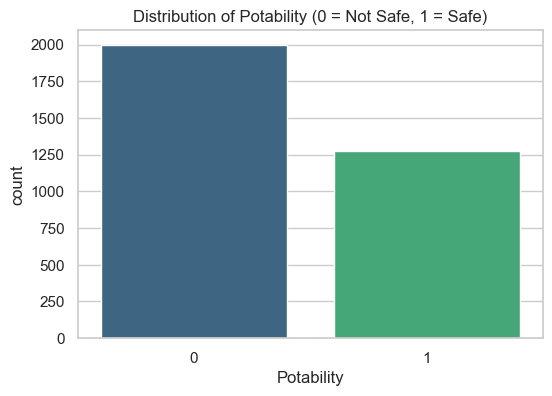

In [17]:
# Check for missing values
print("Missing Values Before Imputation:\n")
print(df.isnull().sum())

# Visualize the distribution of the target variable to check for class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Potability', palette='viridis')
plt.title('Distribution of Potability (0 = Not Safe, 1 = Safe)')
plt.show()

In [18]:
# Initialize the imputer to fill missing values with the median of each column
imputer = SimpleImputer(strategy='median')

# Apply imputation and keep the dataframe format
df_cleaned = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Verify missing values are handled
print("Missing Values After Imputation:\n")
print(df_cleaned.isnull().sum())

Missing Values After Imputation:

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [19]:
# Separate features (X) and target (y)
X = df_cleaned.drop('Potability', axis=1)
y = df_cleaned['Potability']

# Split the data - 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (2620, 9)
Testing data shape: (656, 9)


In [20]:
# Initialize the Standard Scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data (Do NOT fit on test data to prevent data leakage)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully!")

Data scaled successfully!


In [21]:
# Initialize a dictionary of models to test
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine (SVC)': SVC(random_state=42)
}

best_model_name = None
best_accuracy = 0
best_model = None

print("--- Model Performance ---")

# Loop through each model, train, and test
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.4f}")
    
    # Keep track of the best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_model = model

print(f"\nBest Performing Model: {best_model_name} with Accuracy = {best_accuracy:.4f}")

# Detailed report for the best model
print(f"\n--- Classification Report for {best_model_name} ---")
best_y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, best_y_pred))

--- Model Performance ---
Logistic Regression: 0.6280
Random Forest: 0.6738
Gradient Boosting: 0.6692
Support Vector Machine (SVC): 0.6905

Best Performing Model: Support Vector Machine (SVC) with Accuracy = 0.6905

--- Classification Report for Support Vector Machine (SVC) ---
              precision    recall  f1-score   support

         0.0       0.69      0.91      0.79       412
         1.0       0.68      0.32      0.43       244

    accuracy                           0.69       656
   macro avg       0.69      0.61      0.61       656
weighted avg       0.69      0.69      0.66       656



In [22]:
import joblib

# Save the best model (SVC from Cell 7)
model_filename = 'best_water_model.pkl'
joblib.dump(best_model, model_filename)

# Save the scaler
scaler_filename = 'scaler.pkl'
joblib.dump(scaler, scaler_filename)

print(f"Successfully exported '{model_filename}' and '{scaler_filename}'!")
print("The backend pipeline is fully complete. Time to build the UI!")

Successfully exported 'best_water_model.pkl' and 'scaler.pkl'!
The backend pipeline is fully complete. Time to build the UI!
